# Lesson 9: Segmentation

- In the classroom, the libraries are already installed for you.
- If you would like to run this code on your own machine, you can install the following:

```
    !pip install transformers
    !pip install gradio
    !pip install timm
    !pip install torchvision
```

- Here is some code that suppresses warning messages.

In [1]:
from transformers.utils import logging
logging.set_verbosity_error()

### Mask Generation with SAM

The [Segment Anything Model (SAM)](https://segment-anything.com) model was released by Meta AI.

In [2]:
from transformers import pipeline

In [3]:
sam_pipe = pipeline("mask-generation",
    "./models/Zigeng/SlimSAM-uniform-77")

Info about [Zigeng/SlimSAM-uniform-77](https://huggingface.co/Zigeng/SlimSAM-uniform-77)

In [4]:
from PIL import Image

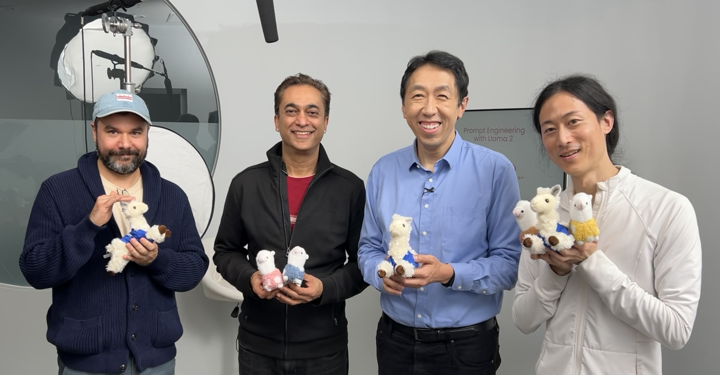

In [5]:
raw_image = Image.open('meta_llamas.jpg')
raw_image.resize((720, 375))

- Running this will take some time
- The higher the value of 'points_per_batch', the more efficient pipeline inference will be

In [6]:
output = sam_pipe(raw_image, points_per_batch=32)

In [7]:
from helper import show_pipe_masks_on_image

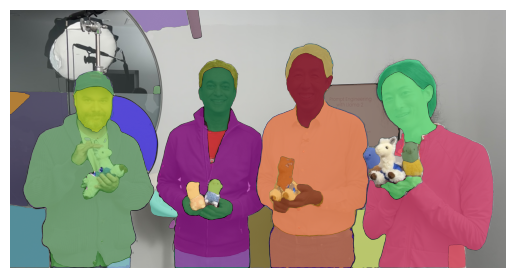

In [8]:
show_pipe_masks_on_image(raw_image, output)

_Note:_ The colors of segmentation, that you will get when running this code, might be different than the ones you see in the video.

### Faster Inference: Infer an Image and a Single Point

In [9]:
from transformers import SamModel, SamProcessor

In [10]:
model = SamModel.from_pretrained(
    "./models/Zigeng/SlimSAM-uniform-77")

processor = SamProcessor.from_pretrained(
    "./models/Zigeng/SlimSAM-uniform-77")

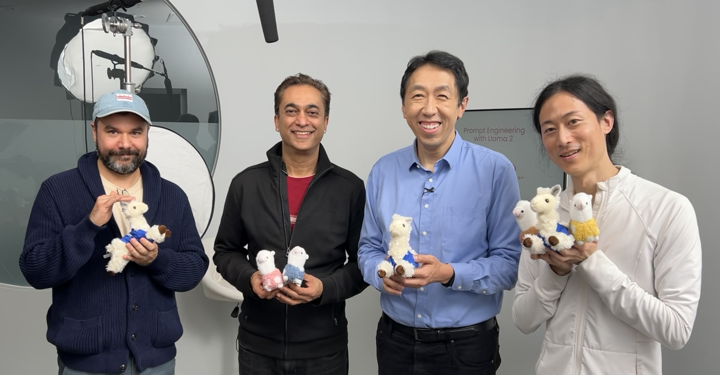

In [11]:
raw_image.resize((720, 375))

- Segment the blue shirt Andrew is wearing.
- Give any single 2D point that would be in that region (blue shirt).

In [12]:
input_points = [[[1600, 700]]]

- Create the input using the image and the single point.
- `return_tensors="pt"` means to return PyTorch Tensors.

In [13]:
inputs = processor(raw_image,
                 input_points=input_points,
                 return_tensors="pt")

- Given the inputs, get the output from the model.

In [14]:
import torch

In [15]:
with torch.no_grad():
    outputs = model(**inputs)

In [16]:
predicted_masks = processor.image_processor.post_process_masks(
    outputs.pred_masks,
    inputs["original_sizes"],
    inputs["reshaped_input_sizes"]
)

 Length of `predicted_masks` corresponds to the number of images that are used in the input.

In [17]:
len(predicted_masks)

1

- Inspect the size of the first ([0]) predicted mask

In [18]:
predicted_mask = predicted_masks[0]
predicted_mask.shape

torch.Size([1, 3, 1500, 2880])

In [19]:
outputs.iou_scores

tensor([[[0.9583, 0.9551, 0.9580]]])

In [20]:
from helper import show_mask_on_image

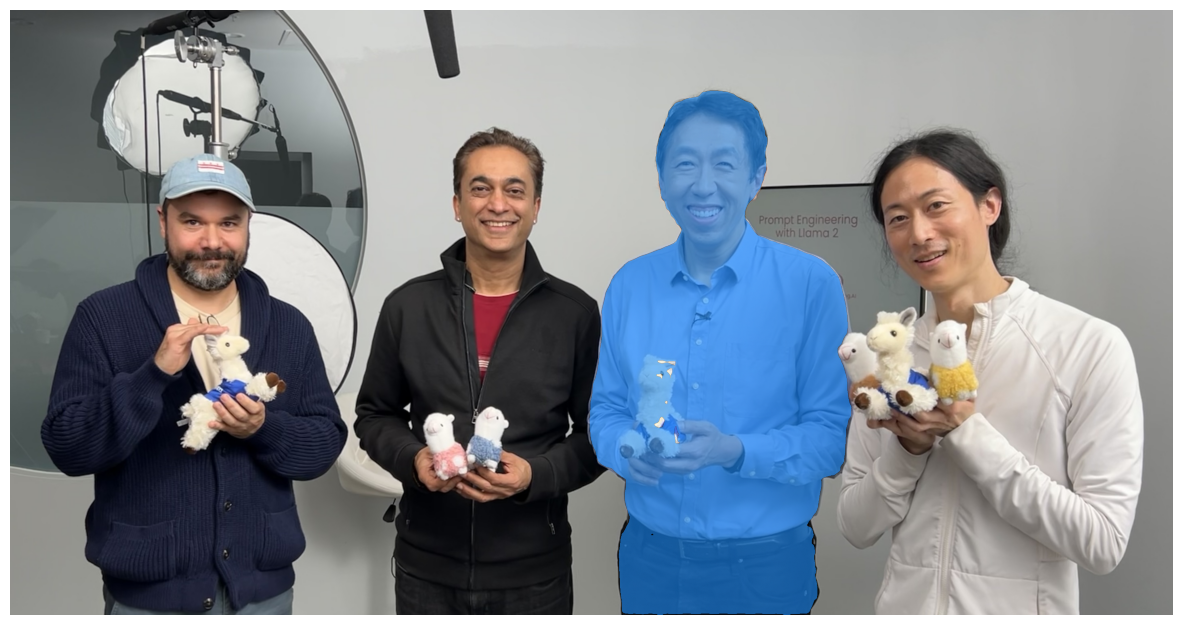

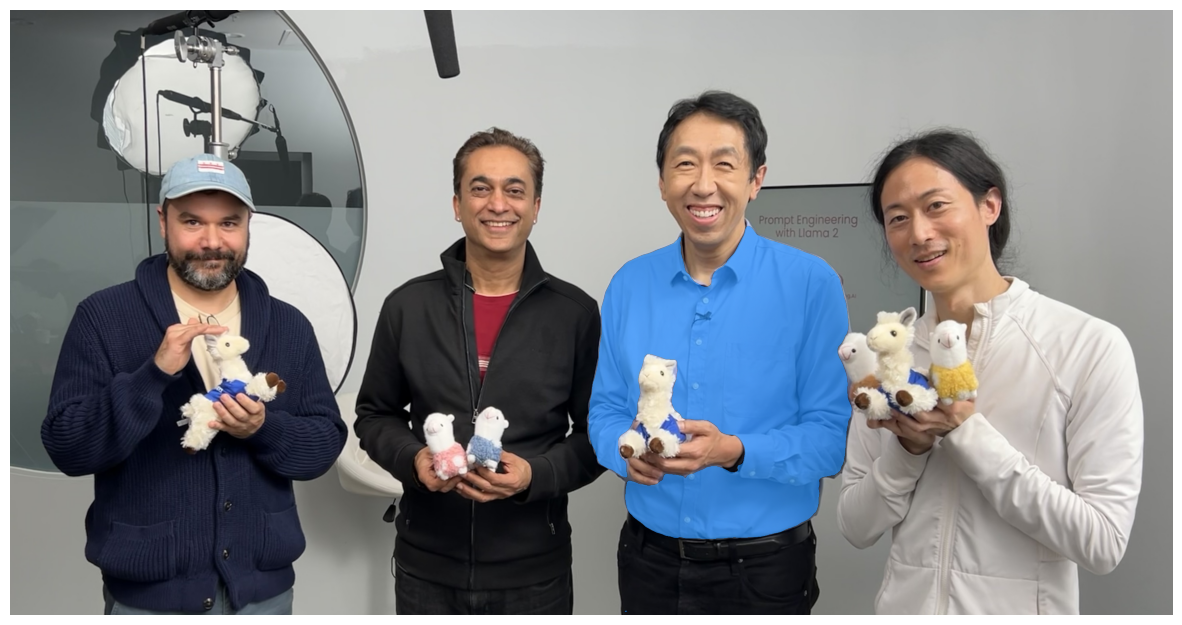

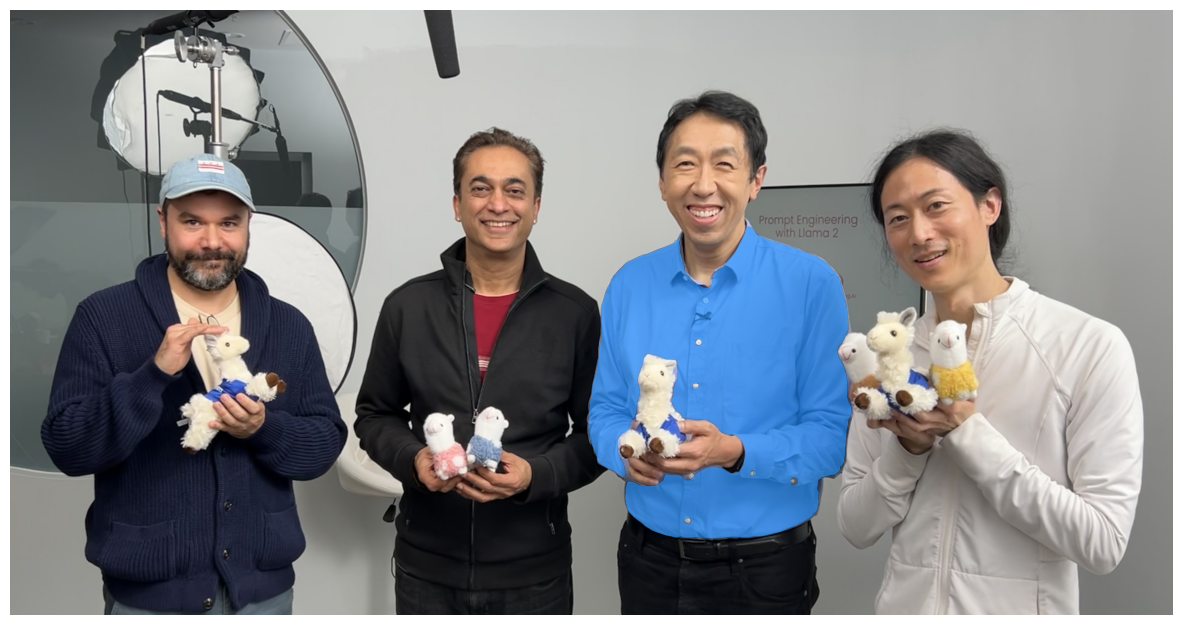

In [21]:
for i in range(3):
    show_mask_on_image(raw_image, predicted_mask[:, i])

## Depth Estimation with DPT

- This model was introduced in the paper [Vision Transformers for Dense Prediction](https://arxiv.org/abs/2103.13413) by Ranftl et al. (2021) and first released in [isl-org/DPT](https://github.com/isl-org/DPT).

In [22]:
depth_estimator = pipeline(task="depth-estimation",
                        model="./models/Intel/dpt-hybrid-midas")

Info about ['Intel/dpt-hybrid-midas'](https://huggingface.co/Intel/dpt-hybrid-midas)

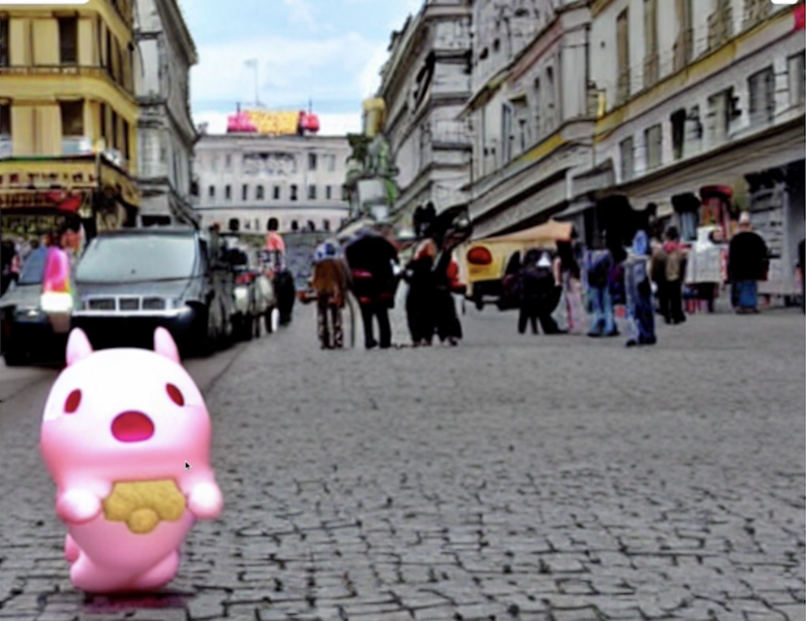

In [23]:
raw_image = Image.open('gradio_tamagochi_vienna.png')
raw_image.resize((806, 621))

- If you'd like to generate this image or something like it, check out the short course on [Gradio](https://www.deeplearning.ai/short-courses/building-generative-ai-applications-with-gradio/) and go to the lesson "Image Generation App".

In [24]:
output = depth_estimator(raw_image)

In [25]:
output

{'predicted_depth': tensor([[[ 248.4070,  252.1828,  256.9171,  ...,  595.8297,  591.8107,
            471.2295],
          [ 247.3371,  254.8536,  257.9679,  ...,  596.0247,  589.0451,
            594.1439],
          [ 259.7675,  259.5481,  261.4167,  ...,  597.6286,  595.3369,
            595.7493],
          ...,
          [3014.1089, 3018.4839, 3019.1711,  ..., 3275.2754, 3269.3459,
           3268.8362],
          [3041.5544, 3040.2783, 3044.4622,  ..., 3280.7471, 3289.3652,
           3274.8696],
          [3039.7483, 3056.0349, 3052.9739,  ..., 3301.9993, 3298.1875,
           3286.9126]]]),
 'depth': <PIL.Image.Image image mode=L size=1612x1242>}

- Post-process the output image to resize it to the size of the original image.

In [26]:
output["predicted_depth"].shape

torch.Size([1, 384, 384])

In [27]:
output["predicted_depth"].unsqueeze(1).shape

torch.Size([1, 1, 384, 384])

In [28]:
prediction = torch.nn.functional.interpolate(
    output["predicted_depth"].unsqueeze(1),
    size=raw_image.size[::-1],
    mode="bicubic",
    align_corners=False,
)

In [29]:
prediction.shape

torch.Size([1, 1, 1242, 1612])

In [30]:
raw_image.size[::-1],

((1242, 1612),)

In [31]:
prediction

tensor([[[[ 248.1577,  248.2614,  248.7576,  ...,  468.0627,  447.0034,
            442.8550],
          [ 248.0309,  248.1445,  248.6918,  ...,  477.7614,  458.3928,
            454.5768],
          [ 247.0836,  247.2386,  247.9993,  ...,  508.8532,  494.9498,
            492.2080],
          ...,
          [3040.0381, 3040.3979, 3042.2317,  ..., 3285.1279, 3283.1458,
           3282.7566],
          [3037.8704, 3038.3865, 3041.0278,  ..., 3288.0640, 3286.3352,
           3285.9907],
          [3037.5505, 3038.1133, 3040.9949,  ..., 3289.0688, 3287.3901,
           3287.0542]]]])

- Normalize the predicted tensors (between 0 and 255) so that they can be displayed.

In [32]:
import numpy as np 

In [33]:
output = prediction.squeeze().numpy()
formatted = (output * 255 / np.max(output)).astype("uint8")
depth = Image.fromarray(formatted)

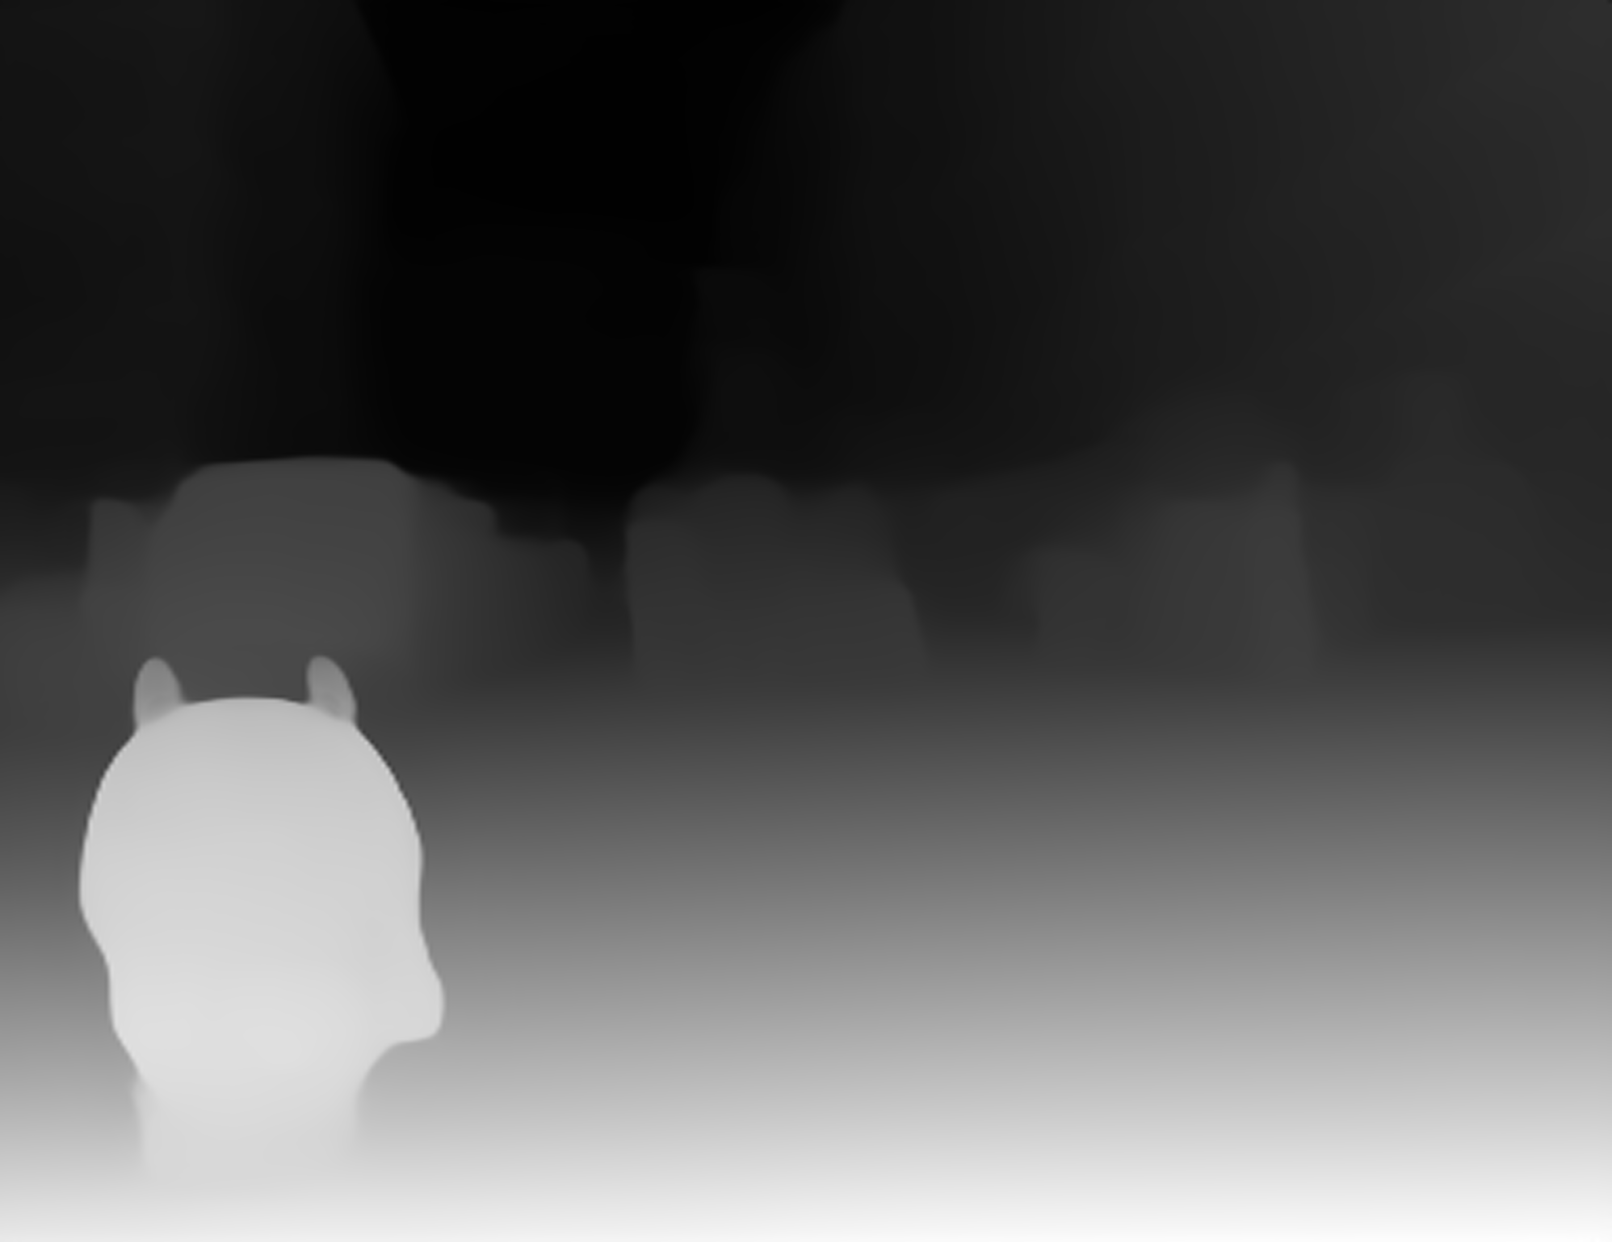

In [34]:
depth

### Demo using Gradio

### Troubleshooting Tip
- Note, in the classroom, you may see the code for creating the Gradio app run indefinitely.
  - This is specific to this classroom environment when it's serving many learners at once, and you won't wouldn't experience this issue if you run this code on your own machine.
- To fix this, please restart the kernel (Menu Kernel->Restart Kernel) and re-run the code in the lab from the beginning of the lesson.

In [35]:
import os
import gradio as gr
from transformers import pipeline

In [36]:
def launch(input_image):
    out = depth_estimator(input_image)

    # resize the prediction
    prediction = torch.nn.functional.interpolate(
        out["predicted_depth"].unsqueeze(1),
        size=input_image.size[::-1],
        mode="bicubic",
        align_corners=False,
    )

    # normalize the prediction
    output = prediction.squeeze().numpy()
    formatted = (output * 255 / np.max(output)).astype("uint8")
    depth = Image.fromarray(formatted)
    return depth

In [37]:
iface = gr.Interface(launch, 
                     inputs=gr.Image(type='pil'), 
                     outputs=gr.Image(type='pil'))

IMPORTANT: You are using gradio version 4.16.0, however version 4.44.1 is available, please upgrade.
--------


In [38]:
iface.launch(share=True, server_port=int(os.environ['PORT1']))

Running on local URL:  https://0.0.0.0:8000
Running on public URL: https://85e0f891d193e94896.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


In [39]:
iface.close()

Closing server running on port: 8000


### Close the app
- Remember to call `.close()` on the Gradio app when you're done using it.

### Try it yourself! 
- Try this model with your own images!